## Earthquake Data

In [1]:
import numpy as np
import pandas as pd

In [2]:
url = 'https://raw.githubusercontent.com/plotly/datasets/master/earthquakes-23k.csv'
df = pd.read_csv(url); print(df)

             Date  Latitude  Longitude  Magnitude
0      01/02/1965   19.2460   145.6160        6.0
1      01/04/1965    1.8630   127.3520        5.8
2      01/05/1965  -20.5790  -173.9720        6.2
3      01/08/1965  -59.0760   -23.5570        5.8
4      01/09/1965   11.9380   126.4270        5.8
...           ...       ...        ...        ...
23407  12/28/2016   38.3917  -118.8941        5.6
23408  12/28/2016   38.3777  -118.8957        5.5
23409  12/28/2016   36.9179   140.4262        5.9
23410  12/29/2016   -9.0283   118.6639        6.3
23411  12/30/2016   37.3973   141.4103        5.5

[23412 rows x 4 columns]


**(a) Looking at the data**
  - (i) What is the range of magnitudes?
  - (ii) What are the mean and median magnitudes?
  - (iii) At which location(s) was the strongest earthquake recorded?


In [3]:
df.describe()

,Latitude,Longitude,Magnitude
count,23412.000000,23412.000000,23412.000000
mean,1.679033,39.639961,5.882531
std,30.113183,125.511959,0.423066
min,-77.080000,-179.997000,5.500000
25%,-18.653000,-76.349750,5.600000
50%,-3.568500,103.982000,5.700000
75%,26.190750,145.026250,6.000000
max,86.005000,179.998000,9.100000


In [4]:
max_mag = df["Magnitude"].max()
tmp = df[df["Magnitude"] == max_mag]
tmp

,Date,Latitude,Longitude,Magnitude
17083,12/26/2004,3.295,95.982,9.1
20501,03/11/2011,38.297,142.373,9.1


- (i) 5.5 to 9.1
- (ii) The mean is 5.88 and the median 5.70
- (iii) Off the coasts of Sumatra and Japan


**(b) Show the distribution of magnitudes in a histogram**

Text(0, 0.5, 'Number')

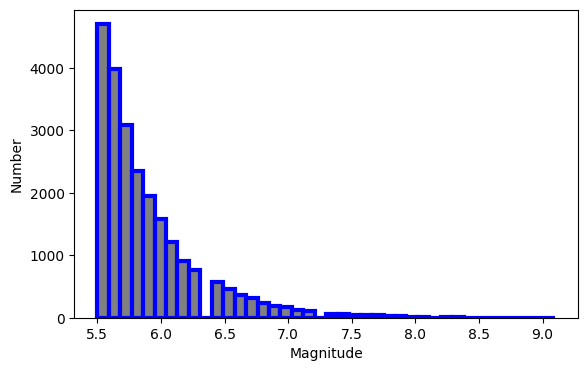

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6.5,4))
plt.hist(df["Magnitude"],bins=40,facecolor="grey", edgecolor='b', linewidth=3)
plt.xlabel('Magnitude')
plt.ylabel('Number')

**(c) Produce bar plots of:**
 - (i) The number of earthquakes grouped by the month name
 -  (ii) The mean magnitude grouped by the month name.

In [8]:
# FIRST GROUP BY MONTH
df['Month'] = df['Date'].str.rsplit('/').str[0] # Extracts first element before '/' on string
df

,Date,Latitude,Longitude,Magnitude,Month
0,01/02/1965,19.2460,145.6160,6.0,01
1,01/04/1965,1.8630,127.3520,5.8,01
2,01/05/1965,-20.5790,-173.9720,6.2,01
3,01/08/1965,-59.0760,-23.5570,5.8,01
4,01/09/1965,11.9380,126.4270,5.8,01
...,...,...,...,...,...
23407,12/28/2016,38.3917,-118.8941,5.6,12
23408,12/28/2016,38.3777,-118.8957,5.5,12
23409,12/28/2016,36.9179,140.4262,5.9,12
23410,12/29/2016,-9.0283,118.6639,6.3,12


In [12]:
# NAMING THE MONTHS
month_map = {'01': 'January', '02': 'February', '03': 'March', '04': 'April', '05': 
             'May', '06': 'June', '07': 'July', '08': 'August', '09': 'September', 
             '10': 'October', '11': 'November', '12': 'December'}
df['month'] = df['Month'].map(month_map)
df

,Date,Latitude,Longitude,Magnitude,Month,month
0,01/02/1965,19.2460,145.6160,6.0,01,January
1,01/04/1965,1.8630,127.3520,5.8,01,January
2,01/05/1965,-20.5790,-173.9720,6.2,01,January
3,01/08/1965,-59.0760,-23.5570,5.8,01,January
4,01/09/1965,11.9380,126.4270,5.8,01,January
...,...,...,...,...,...,...
23407,12/28/2016,38.3917,-118.8941,5.6,12,December
23408,12/28/2016,38.3777,-118.8957,5.5,12,December
23409,12/28/2016,36.9179,140.4262,5.9,12,December
23410,12/29/2016,-9.0283,118.6639,6.3,12,December


- (i) The number of earthquakes grouped by the month name

In [20]:
no = df.groupby('month')['Magnitude'].count()
order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 
         'September', 'October', 'November', 'December']
no= no.reindex(order, axis=0) # REORDERING BY MONTH
type(no) # NOT LETTING ME TREAT AS A DATAFRAME SINCE IT HAS PRODUCED A SERIES
nos = no.to_frame() # CONVERT TO DATAFRAME
nos['month'] = nos.index # TIDY UP AFTER groupby
nos

,Magnitude,month
month,,
January,1891,January
February,1828,February
March,2113,March
April,1970,April
May,1964,May
June,1824,June
July,1880,July
August,2014,August
September,1985,September


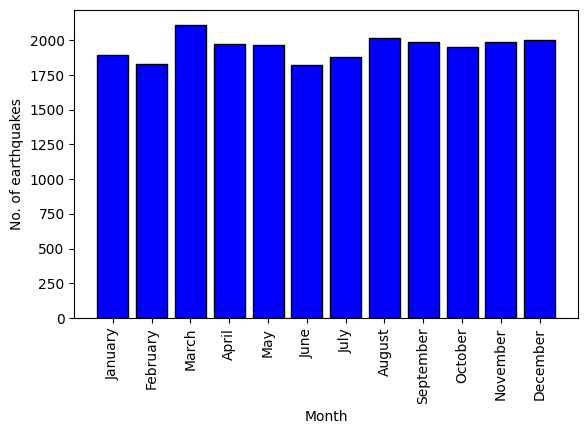

In [25]:
def barplot(data,xpara,ypara,xlabel,ylabel,rot,flag):
    plt.figure(figsize=(6.5,4))
    plt.bar(data[xpara],data[ypara], facecolor = 'b', edgecolor ='k')
    plt.xticks(rotation=rot)
    plt.xlabel(xlabel); plt.ylabel(ylabel) 
barplot(nos,'month','Magnitude','Month','No. of earthquakes',90,'nos')

-  (ii) The mean magnitude grouped by the month name.

In [28]:
# AS ABOVE
ave = df.groupby('month')['Magnitude'].mean()
ave = ave.reindex(order, axis=0) 
aves = ave.to_frame() 
aves['month'] = aves.index 
aves

,Magnitude,month
month,,
January,5.874849,January
February,5.877188,February
March,5.874633,March
April,5.897411,April
May,5.890214,May
June,5.874271,June
July,5.885883,July
August,5.894374,August
September,5.873804,September


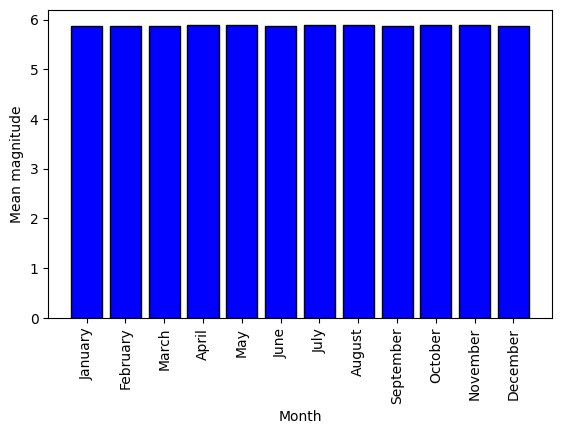

In [29]:
barplot(aves,'month','Magnitude','Month','Mean magnitude',90,'ave')

**(d) Plot the magnitudes versus the date**

In [31]:
# df['date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')
# ValueError: time data '1975-02-23T02:58:41.000Z' does not match format '%m/%d/%Y' (match)

Looks like we have dodgey dates (of course). Various way to find these - I looked for those which has a different length to the others

In [33]:
df['d'] = df['Date'].str.len()
df[df['d'] != 10] # ONLY 3 WHICH DON'T HAVE A LENGTH OF 10 - JUST REMOVE

,Date,Latitude,Longitude,Magnitude,Month,month,d
3378,1975-02-23T02:58:41.000Z,8.017,124.075,5.6,1975-02-23T02:58:41.000Z,NaN,24
7512,1985-04-28T02:53:41.530Z,-32.998,-71.766,5.6,1985-04-28T02:53:41.530Z,NaN,24
20650,2011-03-13T02:23:34.520Z,36.344,142.344,5.8,2011-03-13T02:23:34.520Z,NaN,24


In [36]:
df1 = df[df['d'] == 10] 
df1['date'] = pd.to_datetime(df1['Date'], format='%m/%d/%Y') # THAT'S BETTER - APART FROM THE WARNING

/var/folders/pb/dhr60dvd19370mv4qdxrn34m0000gn/T/ipykernel_92958/2535355418.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['date'] = pd.to_datetime(df1['Date'], format='%m/%d/%Y') # THAT'S BETTER - APART FROM THE WARNING


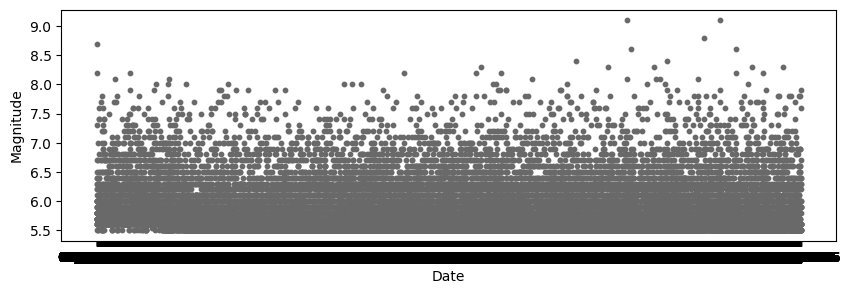

In [46]:
plt.figure(figsize=(10,3))
plt.scatter(df1['Date'],df1['Magnitude'],s=10,c='dimgrey') 
plt.xlabel('Date'); plt.ylabel('Magnitude') # WILL TAKE A WHILE - * SHOWS THAT IT'S THINKING
plt.show()

**(e) You’ll notice this took ages and is a bit of a mess, try to show this is in a clearer format**

In [41]:
df1['Year'] = df['Date'].str.rsplit('/').str[2]
df1

/var/folders/pb/dhr60dvd19370mv4qdxrn34m0000gn/T/ipykernel_92958/3405228797.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Year'] = df['Date'].str.rsplit('/').str[2]


,Date,Latitude,Longitude,Magnitude,Month,month,d,date,Year
0,01/02/1965,19.2460,145.6160,6.0,01,January,10,1965-01-02,1965
1,01/04/1965,1.8630,127.3520,5.8,01,January,10,1965-01-04,1965
2,01/05/1965,-20.5790,-173.9720,6.2,01,January,10,1965-01-05,1965
3,01/08/1965,-59.0760,-23.5570,5.8,01,January,10,1965-01-08,1965
4,01/09/1965,11.9380,126.4270,5.8,01,January,10,1965-01-09,1965
...,...,...,...,...,...,...,...,...,...
23407,12/28/2016,38.3917,-118.8941,5.6,12,December,10,2016-12-28,2016
23408,12/28/2016,38.3777,-118.8957,5.5,12,December,10,2016-12-28,2016
23409,12/28/2016,36.9179,140.4262,5.9,12,December,10,2016-12-28,2016
23410,12/29/2016,-9.0283,118.6639,6.3,12,December,10,2016-12-29,2016


In [42]:
ave = df1.groupby('Year')['Magnitude'].mean()
aves = ave.to_frame() 
aves['Year'] = aves.index
aves

,Magnitude,Year
Year,,
1965,6.014159,1965
1966,6.040470,1966
1967,6.003922,1967
1968,6.078525,1968
1969,6.009350,1969
1970,6.035768,1970
1971,5.972539,1971
1972,5.943814,1972
1973,5.814065,1973


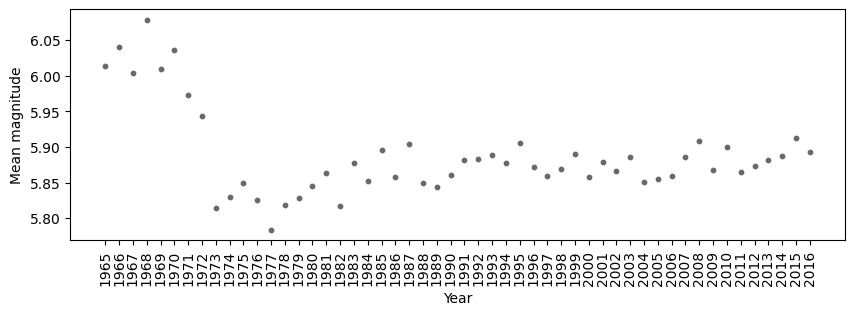

In [48]:
plt.figure(figsize=(10,3))
plt.scatter(aves['Year'],aves['Magnitude'],s=10,c='dimgrey')
plt.xlabel('Year'); plt.ylabel('Mean magnitude')
plt.xticks(rotation=90)
plt.show()

**(g) Plot the latitude and longitude of the earthquakes using a third ’dimension’ for the magnitudes (e.g. size/colour of marker or a heatmap)**

/var/folders/pb/dhr60dvd19370mv4qdxrn34m0000gn/T/ipykernel_92958/154711015.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.sort_values(by=["Magnitude"], inplace=True, ascending=True) # PUTTING STRONGEST ON TOP


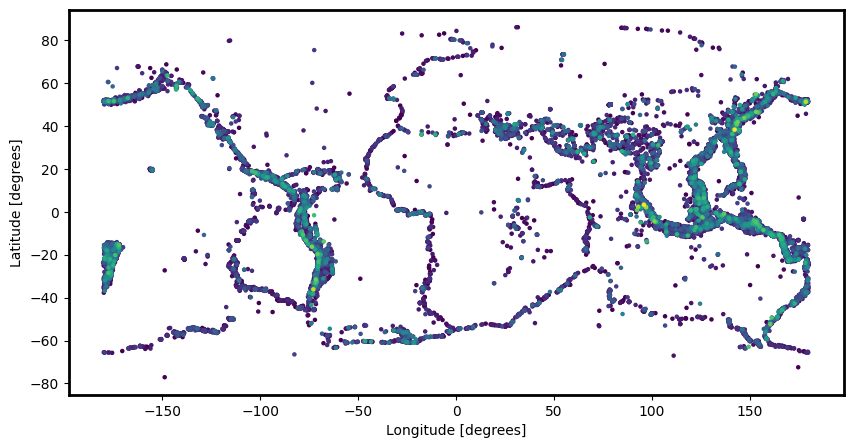

In [49]:
df1.sort_values(by=["Magnitude"], inplace=True, ascending=True) # PUTTING STRONGEST ON TOP

plt.figure(figsize=(10,5))
ax = plt.gca() 
plt.setp(ax.spines.values(), linewidth=2)
plt.scatter(df1['Longitude'],df1['Latitude'],s=5,c=df1['Magnitude'])
plt.xlabel('Longitude [degrees]'); plt.ylabel('Latitude [degrees]')
plt.show()

**If you are really motivated, you could try and superimpose this on a map of the world**

 - Option 1 (interactive)

In [52]:
import plotly.express as px
import plotly.graph_objects as go

#ms = "stamen-terrain"
ms = "open-street-map"
#ms = 'carto-positron'

fig = px.density_mapbox(df1, lat='Latitude', lon='Longitude', z='Magnitude', radius=3,
                            center=dict(lat=0, lon=180), zoom=0,mapbox_style=ms)
fig.show()

- Option 2 (more work, but *may* be better for documents)

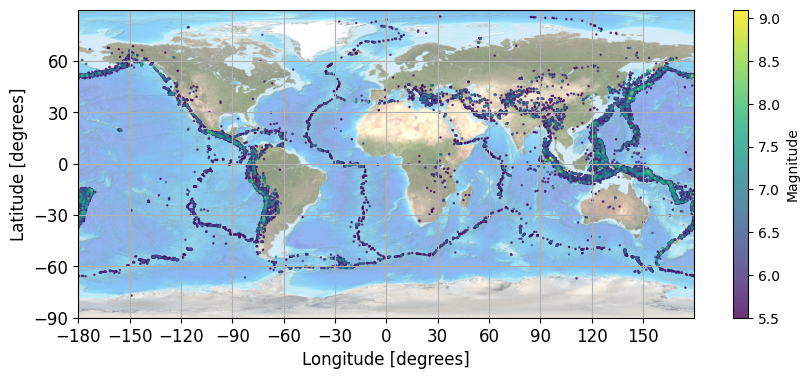

In [67]:
import matplotlib.image as mpimg
cmap = 'gist_rainbow'
font = 12
world=mpimg.imread('2560px-Large_World_Physical_Map.png')
df1
mags = df1.plot(kind="scatter", x="Longitude", y="Latitude",c="Magnitude", 
                s=df1["Magnitude"]/10,colorbar=True,
                fontsize = font, alpha=0.8, figsize=(10,4))
plt.imshow(world, extent=[-180, 180, -90, 90], alpha=0.5) 
ticks_x = [x for  x in range(-180,180) if x%30 ==0]
ticks_y = [x for  x in range(-90,90) if x%30 ==0]
plt.xticks(ticks_x); plt.yticks(ticks_y)
plt.xlabel('Longitude [degrees]',fontsize = font); plt.ylabel('Latitude [degrees]',fontsize = font)
plt.grid(which='major', axis='both', linestyle='-')

**(h) And, not for the faint-hearted, if you are really motivated, use countries.csv to rank the world’s countries by the average earthquake strength**

In [68]:
coun  = pd.read_csv('countries.csv'); print(coun)

               Country Alpha-2 code Alpha-3 code  Numeric code  \
0          Afghanistan           AF          AFG             4   
1              Albania           AL          ALB             8   
2              Algeria           DZ          DZA            12   
3       American Samoa           AS          ASM            16   
4              Andorra           AD          AND            20   
..                 ...          ...          ...           ...   
239  Wallis and Futuna           WF          WLF           876   
240     Western Sahara           EH          ESH           732   
241              Yemen           YE          YEM           887   
242             Zambia           ZM          ZMB           894   
243           Zimbabwe           ZW          ZWE           716   

     Latitude (average)  Longitude (average)  
0               33.0000                 65.0  
1               41.0000                 20.0  
2               28.0000                  3.0  
3              -14.

In [71]:
from sklearn.neighbors import BallTree

e = df[['Latitude','Longitude']] # Earthquake coords
e['Latitude'] = e['Latitude']*np.pi/180  # TO RADIANS
e['Longitude'] = e['Longitude']*np.pi/180
E = e.to_numpy() # BallTree JUST WORKS WITH ARRAYS
#E

/var/folders/pb/dhr60dvd19370mv4qdxrn34m0000gn/T/ipykernel_92958/297871975.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/pb/dhr60dvd19370mv4qdxrn34m0000gn/T/ipykernel_92958/297871975.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



array([[ 0.33590607,  2.54147864],
       [ 0.03251548,  2.22271171],
       [-0.35917131, -3.03638421],
       ...,
       [ 0.64433891,  2.45089955],
       [-0.15757356,  2.07107576],
       [ 0.65270602,  2.46807533]])

In [72]:
c = coun[['Latitude (average)','Longitude (average)']] # country coords
c['Latitude (average)'] = c['Latitude (average)']*np.pi/180
c['Longitude (average)'] =c['Longitude (average)']*np.pi/180
C = c.to_numpy()
#C

/var/folders/pb/dhr60dvd19370mv4qdxrn34m0000gn/T/ipykernel_92958/3142599814.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/pb/dhr60dvd19370mv4qdxrn34m0000gn/T/ipykernel_92958/3142599814.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



array([[ 0.57595865,  1.13446401],
       [ 0.71558499,  0.34906585],
       [ 0.48869219,  0.05235988],
       [-0.25016328, -2.96705973],
       [ 0.74176493,  0.02792527],
       [-0.21816616,  0.32288591],
       [ 0.31852259, -1.10246689],
       [-1.57079633,  0.        ],
       [ 0.29757864, -1.07861348],
       [-0.59341195, -1.11701072],
       [ 0.6981317 ,  0.78539816],
       [ 0.21816616, -1.22114928],
       [-0.4712389 ,  2.32128791],
       [ 0.82612193,  0.23270999],
       [ 0.70685835,  0.82903139],
       [ 0.42324234, -1.32645023],
       [ 0.45378561,  0.88226394],
       [ 0.41887902,  1.57079633],
       [ 0.22980227, -1.0390521 ],
       [ 0.9250245 ,  0.48869219],
       [ 0.88720845,  0.06981317],
       [ 0.3010693 , -1.54897971],
       [ 0.16580628,  0.03926991],
       [ 0.56432254, -1.13010069],
       [ 0.47996554,  1.57952297],
       [-0.29670597, -1.13446401],
       [ 0.76794487,  0.31415927],
       [-0.38397244,  0.41887902],
       [-0.95004031,

In [73]:
tree = BallTree(E, metric = 'haversine') # DO THE MATCHING
result = tree.query(C)
# FROM PLAYING AROUND WITH THE AIPORT EXAMPLE AND C = [(-30*np.pi/180,180*np.pi/180)]
# resull GIVES TWO ARRAYS - THE DISTANCE BETWEEN THE CLOSEST MATCH AND THE INDEX
#result

(array([[0.03848156],
        [0.00577823],
        [0.12542685],
        [0.03548288],
        [0.03159986],
        [0.09573766],
        [0.00761798],
        [0.22549654],
        [0.00142521],
        [0.05072296],
        [0.01648222],
        [0.02761165],
        [0.01452971],
        [0.01707129],
        [0.02056304],
        [0.06422934],
        [0.04536274],
        [0.02770264],
        [0.01676551],
        [0.12433028],
        [0.00788975],
        [0.02361806],
        [0.21500419],
        [0.05934878],
        [0.01481011],
        [0.01005196],
        [0.01224652],
        [0.09339839],
        [0.01135224],
        [0.16686299],
        [0.00360206],
        [0.0416449 ],
        [0.01256111],
        [0.19747534],
        [0.02844661],
        [0.10666299],
        [0.11073042],
        [0.18704699],
        [0.06761745],
        [0.00933921],
        [0.05278852],
        [0.18403734],
        [0.00392066],
        [0.01358416],
        [0.0269691 ],
        [0

Very nice, but need to get these back into the data

In [75]:
coun['dist'] = result[0] # ADD TO COUNTRY DATAFRAME
coun['ind'] = result[1]
coun = coun[['ind','dist','Country','Latitude (average)','Longitude (average)']] # TIDY UP

In [76]:
df['ind'] = df.index  # WILL MATCH ON THE INDEX
df_coun = pd.merge(df, coun, on = ['ind'])
df_coun # THESE LOOK LIKE CLOSE MATCHES TO ME

,Date,Latitude,Longitude,Magnitude,Month,month,d,ind,dist,Country,Latitude (average),Longitude (average)
0,08/13/1965,-15.9950,166.9600,6.1,08,August,10,226,0.000677,Vanuatu,-16.0000,167.0000
1,09/26/1965,-54.7570,-38.2440,5.8,09,September,10,271,0.013345,South Georgia and the South Sandwich Islands,-54.5000,-37.0000
2,02/05/1966,39.0930,21.7770,6.2,02,February,10,355,0.003431,Greece,39.0000,22.0000
3,02/07/1966,29.9560,69.7610,6.5,02,February,10,358,0.003694,Pakistan,30.0000,70.0000
4,11/13/1966,17.0420,-61.8850,5.6,11,November,10,550,0.001425,Antigua and Barbuda,17.0500,-61.8000
...,...,...,...,...,...,...,...,...,...,...,...,...
239,12/28/2015,14.6571,-61.3454,5.6,12,December,10,22940,0.013974,Saint Lucia,13.8833,-61.1333
240,12/28/2015,14.6571,-61.3454,5.6,12,December,10,22940,0.024682,Saint Vincent and the Grenadines,13.2500,-61.2000
241,04/20/2016,13.2000,-55.8867,5.6,04,April,10,23077,0.168103,French Guiana,4.0000,-53.0000
242,09/03/2016,36.4251,-96.9291,5.8,09,September,10,23245,0.027505,United States,38.0000,-97.0000


Group by country and rank 

In [77]:
ave = df_coun.groupby('Country')['Magnitude'].mean()
aves = ave.to_frame()
aves['Country'] = aves.index
aves.index.names = ['index']

aves.sort_values(by=['Magnitude'], inplace=True, ascending=False)
aves

,Magnitude,Country
index,,
Nepal,7.8,Nepal
Romania,7.2,Romania
Georgia,7.0,Georgia
Turkmenistan,7.0,Turkmenistan
Montenegro,6.9,Montenegro
...,...,...
Grenada,5.5,Grenada
Sudan,5.5,Sudan
Germany,5.5,Germany


In [78]:
tmp = aves[aves['Country'] == 'New Zealand']; print(tmp)

             Magnitude      Country
index                              
New Zealand        5.8  New Zealand


In [79]:
tmp = aves[aves['Country'] == 'Chile']; print(tmp) # 6.2

       Magnitude Country
index                   
Chile        6.2   Chile
